<a href="https://colab.research.google.com/github/shreyadighe30/Hello/blob/main/Practical2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
from collections import deque
import matplotlib.pyplot as plt
import numpy as np
from google.colab import drive
# 1. Mount Google Drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
import os

def find_file_recursive(root_dir, filename):
    found_paths = []
    for dirpath, dirnames, filenames in os.walk(root_dir):
        if filename in filenames:
            found_paths.append(os.path.join(dirpath, filename))
    return found_paths


file_to_find = 'maze0_dim52.txt'
search_start_path = '/content/drive/MyDrive' # Start searching from the root of My Drive

print(f"Searching for '{file_to_find}' in '{search_start_path}'...")
found_files = find_file_recursive(search_start_path, file_to_find)

if found_files:
    print(f"Found '{file_to_find}' at the following location(s):")
    for path in found_files:
        print(path)
else:
    print(f"'{file_to_find}' not found in '{search_start_path}'. Please ensure it is uploaded and accessible in your Google Drive.")

Searching for 'maze0_dim52.txt' in '/content/drive/MyDrive'...
Found 'maze0_dim52.txt' at the following location(s):
/content/drive/MyDrive/EXP 1 Dataset/Maze Dataset/imperfect_maze/maze0_dim52.txt


In [3]:
import os

for root, dirs, files in os.walk("/content/drive/MyDrive"):
    for file in files:
        if file == "maze0_dim52.txt":
            print(os.path.join(root, file))

/content/drive/MyDrive/EXP 1 Dataset/Maze Dataset/imperfect_maze/maze0_dim52.txt


In [4]:
import numpy as np
from google.colab import drive

drive.mount('/content/drive')

IMPERFECT_MAZE_PATH = "/content/drive/MyDrive/EXP 1 Dataset/Maze Dataset/imperfect_maze/maze0_dim52.txt"

array = np.loadtxt(IMPERFECT_MAZE_PATH, dtype=int)

print(array)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
[[1 1 1 ... 1 1 1]
 [0 0 0 ... 0 0 1]
 [1 1 1 ... 1 0 1]
 ...
 [1 0 0 ... 1 0 1]
 [1 0 0 ... 0 0 0]
 [1 1 1 ... 1 1 1]]


In [5]:
import matplotlib.pyplot as plt

def draw_maze(maze, path=None):
    fig, ax = plt.subplots(figsize=(10,10))

    # Set the border color to white
    fig.patch.set_edgecolor('white')
    fig.patch.set_linewidth(0)

    ax.imshow(maze, cmap=plt.cm.binary, interpolation='nearest')

    # Draw the solution path if it exists
    if path is not None:
        x_coords = [x[1] for x in path]
        y_coords = [y[0] for y in path]
        ax.plot(x_coords, y_coords, color='red', linewidth=2)

    ax.set_xticks([])
    ax.set_yticks([])
    plt.show()


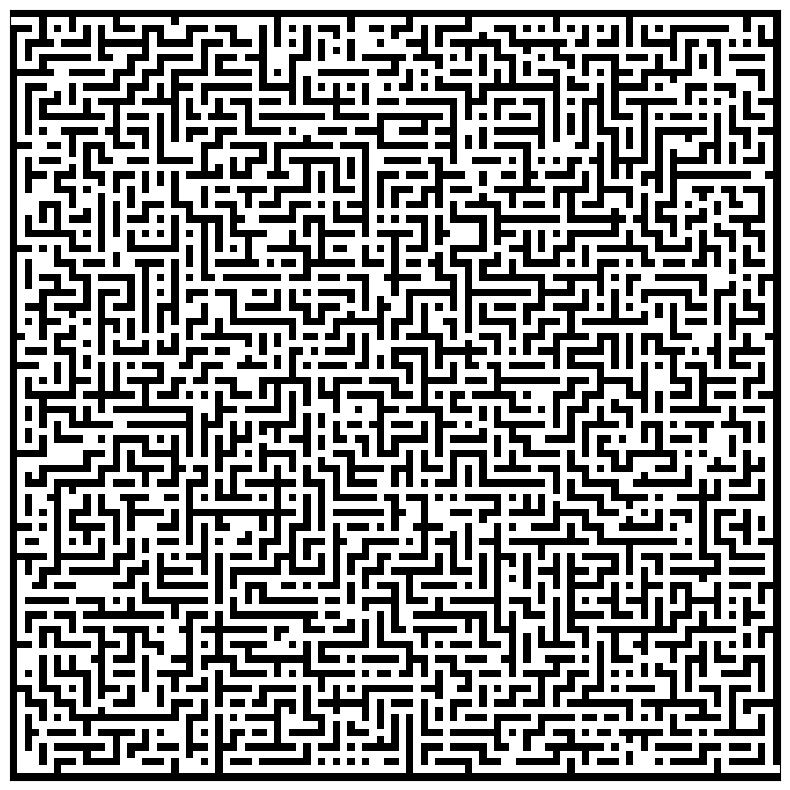

In [6]:
draw_maze(array)

In [7]:
def dfs_maze_solver(maze, start, goal):
    rows, cols = len(maze), len(maze[0])
    visited = [[False] * cols for _ in range(rows)]
    path = []

    def in_bounds(x, y):
        return 0 <= x < rows and 0 <= y < cols

    def dfs(x, y):
        if not in_bounds(x, y) or maze[x][y] == 1 or visited[x][y]:
            return False

        visited[x][y] = True
        path.append((x, y))

        if (x, y) == goal:
            return True
        for dx, dy in [(-1,0), (1,0), (0,-1), (0,1)]:
            if dfs(x + dx, y + dy):
                return True
        path.pop()
        return False

    if dfs(*start):
        return path  # Successful path
    else:
        return None  # No path found


In [8]:
import sys
sys.setrecursionlimit(10**6) # Increase the recursion limit for large mazes

start = (1, 1)  # We start in the upper left corner
end = (array.shape[0]-2, array.shape[1]-2)  # The exit is in the lower right corner

recursive_path = dfs_maze_solver(array, start, end)


In [9]:
def dfs_maze_solver_iterative(maze, start, goal):
    rows, cols = len(maze), len(maze[0])
    visited = [[False for _ in range(cols)] for _ in range(rows)]
    stack = [(start, [start])]  # stack holds tuples of (current_cell, path_so_far)

    def in_bounds(x, y):
        return 0 <= x < rows and 0 <= y < cols

    while stack:
        (x, y), path = stack.pop()

        if not in_bounds(x, y) or maze[x][y] == 1 or visited[x][y]:
            continue

        visited[x][y] = True

        if (x, y) == goal:
            return path  # Found the goal

        # Explore directions: up, down, left, right
        for dx, dy in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
            nx, ny = x + dx, y + dy
            if in_bounds(nx, ny) and not visited[nx][ny] and maze[nx][ny] == 0:
                stack.append(((nx, ny), path + [(nx, ny)]))

    return


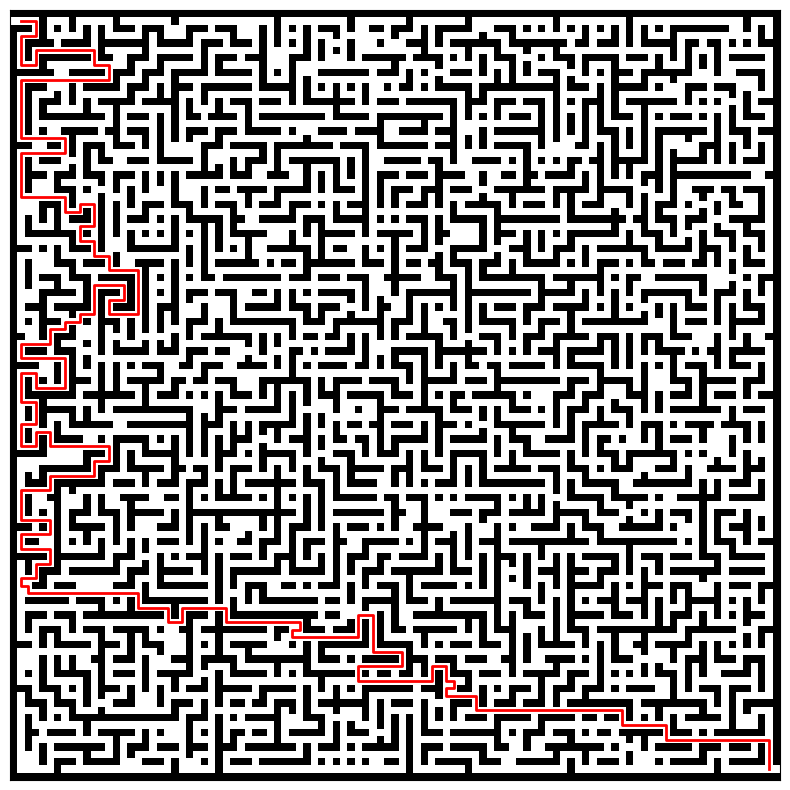

In [10]:
iterative_path = dfs_maze_solver_iterative(array, start, end)
draw_maze(array, path=iterative_path)


In [11]:
from collections import deque

def bfs_maze_solver(maze, start, goal):
    rows, cols = len(maze), len(maze[0])
    visited = [[False for _ in range(cols)] for _ in range(rows)]
    queue = deque([(start, [start])])  # queue holds (cell, path_so_far)

    def in_bounds(x, y):
        return 0 <= x < rows and 0 <= y < cols

    while queue:
        (x, y), path = queue.popleft()

        if not in_bounds(x, y) or maze[x][y] == 1 or visited[x][y]:
            continue

        visited[x][y] = True

        if (x, y) == goal:
            return path

        for dx, dy in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
            nx, ny = x + dx, y + dy
            if in_bounds(nx, ny) and not visited[nx][ny] and maze[nx][ny] == 0:
                queue.append(((nx, ny), path + [(nx, ny)]))

    return None


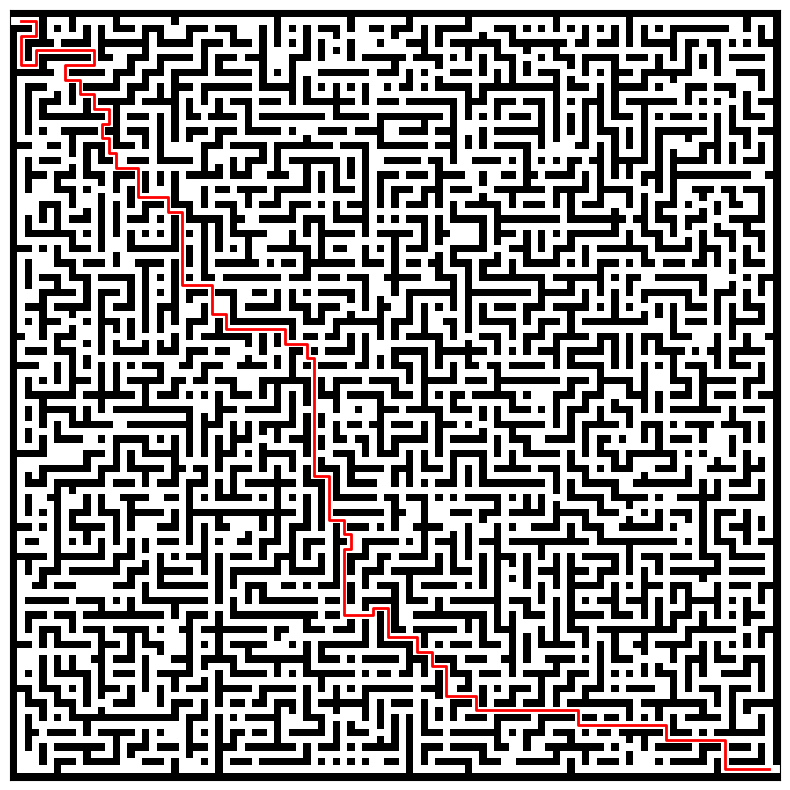

In [12]:
shortest_path = bfs_maze_solver(array, start, end)
draw_maze(array, path=shortest_path)
